# Modeling dataset sturktur protein 1 Dimensi dengan Optuna
(Helix, Sheet, Coil)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

base_dir = "/content/drive/MyDrive/Dataset Protein"

cb513 = np.load(base_dir + "/cb513+profile_split1.npy.gz", allow_pickle=True)
cullpdb = np.load(base_dir + "/cullpdb+profile_5926_filtered.npy.gz", allow_pickle=True)

# reshape
cb513 = cb513.reshape(cb513.shape[0], 700, 57)
cullpdb = cullpdb.reshape(cullpdb.shape[0], 700, 57)

print(cb513.shape)
print(cullpdb.shape)

/tmp/ipykernel_4430/119562786.py:5: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  cb513 = np.load(base_dir + "/cb513+profile_split1.npy.gz", allow_pickle=True)


(514, 700, 57)
(5365, 700, 57)


In [ ]:
#Split data
np.random.seed(42)

n_samples = cullpdb.shape[0]
indices = np.random.permutation(n_samples)

split = int(0.8 * n_samples)

train_idx = indices[:split]
val_idx   = indices[split:]

dataset_train = cullpdb[train_idx]
dataset_val   = cullpdb[val_idx]
dataset_test  = cb513

In [ ]:
def extract(dataset):
    y = dataset[:, :, 21:24] #Q3

    #fitur
    X_aa = dataset[:, :, :21]
    X_other = dataset[:, :, 24:]
    X = np.concatenate([X_aa, X_other], axis=2)

    #mask
    mask = np.sum(X, axis=2) != 0

    return X.astype(np.float32), y.astype(np.float32), mask

#Apply dataset
X_train, y_train, mask_train = extract(dataset_train)
X_val,   y_val,   mask_val   = extract(dataset_val)
X_test,  y_test,  mask_test  = extract(dataset_test)

# Optuna Modeling

In [ ]:
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
def objective(trial):

    # hyperparameter
    filters = trial.suggest_categorical("filters", [32, 64, 128])
    kernel_size = trial.suggest_int("kernel_size", 3, 7)
    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    # model
    input_layer = Input(shape=(700, 54))

    x = Conv1D(filters, kernel_size, padding='same', activation='relu')(input_layer)
    x = Conv1D(filters*2, kernel_size, padding='same', activation='relu')(x)

    x = Dropout(dropout_rate)(x)

    x = TimeDistributed(Dense(64, activation='relu'))(x)
    output = TimeDistributed(Dense(3, activation='softmax'))(x)

    model = Model(inputs=input_layer, outputs=output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # train
    history = model.fit(
        X_train, y_train,
        sample_weight=mask_train.astype(float),
        validation_data=(X_val, y_val, mask_val.astype(float)),
        epochs=5,
        batch_size=16,
        verbose=0
    )

    # best val
    val_acc = max(history.history['val_accuracy'])

    tf.keras.backend.clear_session()

    return val_acc

In [ ]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=20)

print("Best Params:", study.best_params)
print("Best Accuracy:", study.best_value)

[I 2026-04-21 01:41:53,372] A new study created in memory with name: no-name-97858cd6-33fe-48de-bdf0-469427bfcb64
[I 2026-04-21 01:53:54,595] Trial 0 finished with value: 0.7507748603820801 and parameters: {'filters': 32, 'kernel_size': 4, 'dropout': 0.24172692594769177, 'lr': 0.00437591973642267}. Best is trial 0 with value: 0.7507748603820801.
[I 2026-04-21 02:06:18,678] Trial 1 finished with value: 0.7508161664009094 and parameters: {'filters': 64, 'kernel_size': 5, 'dropout': 0.45875559734752325, 'lr': 0.0018575800130833412}. Best is trial 1 with value: 0.7508161664009094.
[I 2026-04-21 02:18:28,402] Trial 2 finished with value: 0.750777542591095 and parameters: {'filters': 32, 'kernel_size': 6, 'dropout': 0.3636283868607666, 'lr': 0.009437212878072533}. Best is trial 1 with value: 0.7508161664009094.
[I 2026-04-21 02:31:03,103] Trial 3 finished with value: 0.7507842183113098 and parameters: {'filters': 128, 'kernel_size': 4, 'dropout': 0.3650565914716669, 'lr': 0.00455498110742634

Best Params: {'filters': 128, 'kernel_size': 7, 'dropout': 0.3236468577758984, 'lr': 0.002465637058293077}
Best Accuracy: 0.7508655190467834


In [ ]:
# Hasil dari Optuna, karena sudah dapat hasil parameter terbaik, jadi gunakan ini aja agar tidak mengulang proses Optuna dari awal
best = {
    'filters' : 128,
    'kernel_size' : 7,
    'dropout' : 0.3236468577758984,
    'lr' : 0.002465637058293077
}

In [ ]:
# variable best parameter jika saat menggunakan Optuna pertama kali, CTRL + /. kalau tidak lanjut aja
# best = study.best_params

input_layer = Input(shape=(700, 54))

x = Conv1D(best['filters'], best['kernel_size'], padding='same', activation='relu')(input_layer)
x = Conv1D(best['filters']*2, best['kernel_size'], padding='same', activation='relu')(x)
x = Dropout(best['dropout'])(x)

x = TimeDistributed(Dense(64, activation='relu'))(x)
output = TimeDistributed(Dense(3, activation='softmax'))(x)

model = Model(inputs=input_layer, outputs=output)

optimizer = tf.keras.optimizers.Adam(learning_rate=best['lr'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 700, 54)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 700, 128)       │        48,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 700, 256)       │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 700, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 700, 64)        │        16,448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 700, 3)         │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,787 (1.12 MB)

 Trainable params: 294,787 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    sample_weight=mask_train.astype(float),
    validation_data=(X_val, y_val, mask_val.astype(float)),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1124s 2s/step - accuracy: 0.7502 - loss: 0.0164 - val_accuracy: 0.7506 - val_loss: 0.0102
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.7518 - loss: 0.0103 - val_accuracy: 0.7508 - val_loss: 0.0098
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.7519 - loss: 0.0097 - val_accuracy: 0.7508 - val_loss: 0.0097
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.7520 - loss: 0.0093 - val_accuracy: 0.7508 - val_loss: 0.0095
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.7520 - loss: 0.0088 - val_accuracy: 0.7509 - val_loss: 0.0096
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.7522 - loss: 0.0084 - val_accuracy: 0.7505 - val_loss: 0.0099
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.7522 - loss: 0.0080 - val_accuracy: 0.7508 - val_loss: 0.0097


In [ ]:
# Test dengan CB513
test_loss, test_acc = model.evaluate(
    X_test, y_test,
    sample_weight=mask_test.astype(float)
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 155s 5s/step - accuracy: 0.8142 - loss: 0.0117


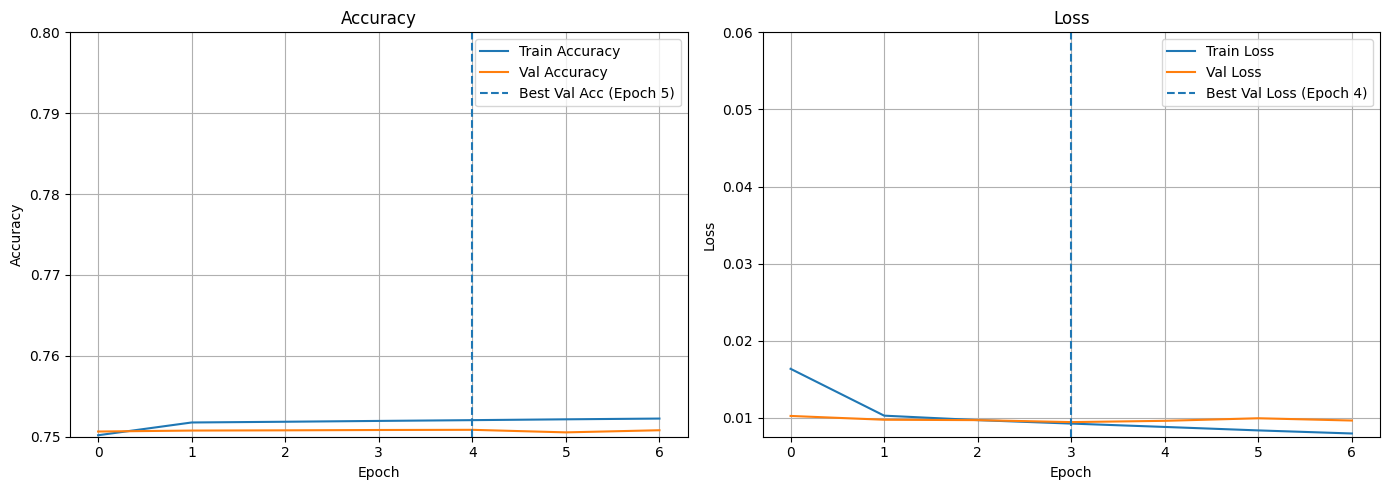

In [ ]:
import matplotlib.pyplot as plt

#Best epoch
best_val_loss_epoch = np.argmin(history.history['val_loss'])
best_val_acc_epoch  = np.argmax(history.history['val_accuracy'])

plt.figure(figsize=(14,5))


#Accurasy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.axvline(best_val_acc_epoch, linestyle='--',
            label=f'Best Val Acc (Epoch {best_val_acc_epoch+1})')

min_acc = min(history.history['val_accuracy'])
max_acc = max(history.history['accuracy'])

plt.yticks(np.arange(round(min_acc, 2), round(max_acc, 2)+0.05, 0.01))

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

#Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.axvline(best_val_loss_epoch, linestyle='--',
            label=f'Best Val Loss (Epoch {best_val_loss_epoch+1})')

min_loss = min(history.history['val_loss'])
max_loss = max(history.history['loss'])

plt.yticks(np.arange(round(min_loss, 2), round(max_loss, 2)+0.05, 0.01))

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()


plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score

# Predict
y_pred = model.predict(X_test)

# Flatten + mask
mask = mask_test.flatten()

y_true = y_test.reshape(-1, 3)[mask]
y_pred = y_pred.reshape(-1, 3)[mask]

# Convert ke label
y_true_label = y_true.argmax(axis=1)
y_pred_label = y_pred.argmax(axis=1)

# Metrics
precision = precision_score(y_true_label, y_pred_label, average='macro')
recall = recall_score(y_true_label, y_pred_label, average='macro')
f1 = f1_score(y_true_label, y_pred_label, average='macro')

# AUC
auc = roc_auc_score(y_true, y_pred, multi_class='ovr')


print("===== FINAL METRICS =====")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"Loss     : {test_loss:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step
===== FINAL METRICS =====
Accuracy : 0.8142
Precision: 0.4409
Recall   : 0.6273
F1 Score : 0.4454
AUC      : 0.9485
Loss     : 0.0117
